# Specifying a Non-steady state groundwater model in flopy

After the steady state model is specified, we will usually move to a non-steady model. In this model there are different **stress-periods** defined by different conditions of recharge or pumping or even constant head boundary. These conditions are constant during each stress period and unique. Each stress periods can be subdivided into different timne steps. The duration of the stress period is a multiple of the time unit.

First we load the necessary libraries.

In [1]:
import numpy as np
import flopy

Then we define the model geometry, the model grid and the model length, width and height.

In [2]:
Lx = 1000.0
Ly = 1000.0
ztop = 10.0
zbot = -50.0
nlay = 1
nrow = 10
ncol = 10
delr = Lx / ncol
delc = Ly / nrow
delv = (ztop - zbot) / nlay
botm = np.linspace(ztop, zbot, nlay + 1)
hk = 1.0
vka = 1.0
sy = 0.1
ss = 1.0e-4
laytyp = 1

We define the ibound conditions and the starting conditions or initial conditions.

In [3]:
ibound = np.ones((nlay, nrow, ncol), dtype=np.int32)
strt = 10.0 * np.ones((nlay, nrow, ncol), dtype=np.float32)

## Defining stress periods

To create a model with multiple stress periods, we need to define the number of periods nper, the period length perlen, the number of time steps nstp, and steady. This is done in the following block in a manner that allows us to pass these variable directly to the discretization object.

In [4]:
nper = 3
perlen = [1, 100, 100]
nstp = [1, 100, 100]
steady = [True, False, False]

## Model setup for time invariant properties: Geometry and sizes

We now define the modelgrid and the time invariant properties of the model.

In [5]:
modelname = "nonsteady_mf"
mf = flopy.modflow.Modflow(modelname, exe_name="mf2005")
dis = flopy.modflow.ModflowDis(
    mf,
    nlay,
    nrow,
    ncol,
    delr=delr,
    delc=delc,
    top=ztop,
    botm=botm[1:],
    nper=nper,
    perlen=perlen,
    nstp=nstp,
    steady=steady,
)
bas = flopy.modflow.ModflowBas(mf, ibound=ibound, strt=strt)
lpf = flopy.modflow.ModflowLpf(
    mf, hk=hk, vka=vka, sy=sy, ss=ss, laytyp=laytyp, ipakcb=53
)
pcg = flopy.modflow.ModflowPcg(mf)

At this point, our model is ready to add our transient boundary packages. First, we will create the GHB object, which is of the following type: flopy.modflow.ModflowGhb().

The key to creating Flopy transient boundary packages is recognizing that the boundary data is stored in a dictionary with key values equal to the zero-based stress period number and values equal to the boundary conditions for that stress period. For a GHB the values can be a two-dimensional nested list of [layer, row, column, stage, conductance].

In [6]:
stageleft = 10.0
stageright = 10.0
bound_sp1 = []
for il in range(nlay):
    condleft = hk * (stageleft - zbot) * delc
    condright = hk * (stageright - zbot) * delc
    for ir in range(nrow):
        bound_sp1.append([il, ir, 0, stageleft, condleft])
        bound_sp1.append([il, ir, ncol - 1, stageright, condright])
print("Adding ", len(bound_sp1), "GHBs for stress period 1.")

Adding  20 GHBs for stress period 1.


Making the list and providing data for stress period 2.

In [7]:
# Make list for stress period 2
stageleft = 10.0
stageright = 0.0
condleft = hk * (stageleft - zbot) * delc
condright = hk * (stageright - zbot) * delc
bound_sp2 = []
for il in range(nlay):
    for ir in range(nrow):
        bound_sp2.append([il, ir, 0, stageleft, condleft])
        bound_sp2.append([il, ir, ncol - 1, stageright, condright])
print("Adding ", len(bound_sp2), "GHBs for stress period 2.")

Adding  20 GHBs for stress period 2.


Copying data if no data are specified for stress period 3.

In [8]:
# We do not need to add a dictionary entry for stress period 3.
# Flopy will automatically take the list from stress period 2 and apply it
# to the end of the simulation
stress_period_data = {0: bound_sp1, 1: bound_sp2}

In [9]:
# Create the flopy ghb object
ghb = flopy.modflow.ModflowGhb(mf, stress_period_data=stress_period_data)

## Defining the output

We now define the output control which is of the type flopy.modflow.ModflowOc().

In [10]:
stress_period_data = {}
for kper in range(nper):
    for kstp in range(nstp[kper]):
        stress_period_data[(kper, kstp)] = [
            "save head",
            "save drawdown",
            "save budget",
            "print head",
            "print budget",
        ]
oc = flopy.modflow.ModflowOc(
    mf, stress_period_data=stress_period_data, compact=True
)

## Running the model

Run the model with the run_model method, which returns a success flag and the stream of output. With run_model, we have some finer control, that allows us to suppress the output.

In [11]:
# Write the model input files
mf.write_input()
# Run the model
success, mfoutput = mf.run_model(silent=True, pause=False)
if not success:
    raise Exception("MODFLOW did not terminate normally.")

## Plotting

In [12]:
# Imports
import matplotlib.pyplot as plt
import flopy.utils.binaryfile as bf

Creating the water budget file.

In [13]:
# Create the headfile and budget file objects
headobj = bf.HeadFile(modelname + ".hds")
times = headobj.get_times()
cbb = bf.CellBudgetFile(modelname + ".cbc")

Making a contour map.

In [14]:
# Setup contour parameters
levels = np.linspace(0, 10, 11)
extent = (delr / 2.0, Lx - delr / 2.0, delc / 2.0, Ly - delc / 2.0)
print("Levels: ", levels)
print("Extent: ", extent)

Levels:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Extent:  (50.0, 950.0, 50.0, 950.0)


## Fixing the location of the well

In [15]:
# Well point for plotting
wpt = (450.0, 550.0)

## Making the map

*****Processing time:  1.0
Head statistics
  min:  10.0
  max:  10.0
  std:  0.0
*****Processing time:  101.0
Head statistics
  min:  0.025931068
  max:  9.998436
  std:  3.2574987
*****Processing time:  201.0
Head statistics
  min:  0.01845504
  max:  9.994668
  std:  3.2088623


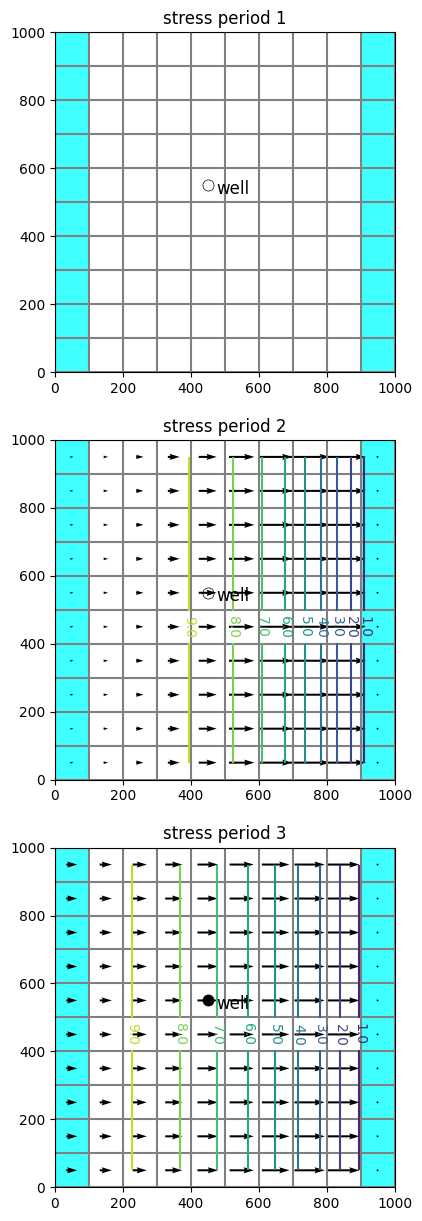

In [16]:
# Make the plots
fig = plt.figure(figsize=(5, 15))
mytimes = [1.0, 101.0, 201.0]
for iplot, time in enumerate(mytimes):
    print("*****Processing time: ", time)
    head = headobj.get_data(totim=time)
    # Print statistics
    print("Head statistics")
    print("  min: ", head.min())
    print("  max: ", head.max())
    print("  std: ", head.std())

    # Extract flow right face and flow front face
    frf = cbb.get_data(text="FLOW RIGHT FACE", totim=time)[0]
    fff = cbb.get_data(text="FLOW FRONT FACE", totim=time)[0]

    # Create a map for this time
    ax = fig.add_subplot(len(mytimes), 1, iplot + 1, aspect="equal")
    ax.set_title("stress period " + str(iplot + 1))

    pmv = flopy.plot.PlotMapView(model=mf, layer=0, ax=ax)
    qm = pmv.plot_ibound()
    lc = pmv.plot_grid()
    qm = pmv.plot_bc("GHB", alpha=0.5)
    if head.min() != head.max():
        cs = pmv.contour_array(head, levels=levels)
        plt.clabel(cs, inline=1, fontsize=10, fmt="%1.1f")
        quiver = pmv.plot_vector(frf, fff)

    mfc = "None"
    if (iplot + 1) == len(mytimes):
        mfc = "black"
    ax.plot(
        wpt[0],
        wpt[1],
        lw=0,
        marker="o",
        markersize=8,
        markeredgewidth=0.5,
        markeredgecolor="black",
        markerfacecolor=mfc,
        zorder=9,
    )
    ax.text(wpt[0] + 25, wpt[1] - 25, "well", size=12, zorder=12)

## Making the hydrograph

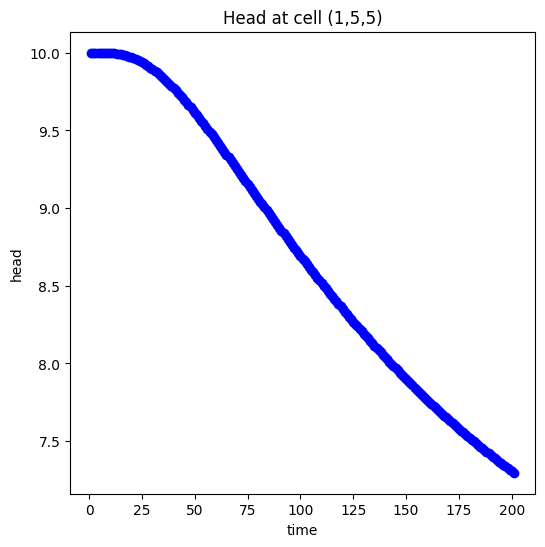

In [17]:
# Plot the head versus time
idx = (0, int(nrow / 2) - 1, int(ncol / 2) - 1)
ts = headobj.get_ts(idx)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
ttl = "Head at cell ({0},{1},{2})".format(idx[0] + 1, idx[1] + 1, idx[2] + 1)
ax.set_title(ttl)
ax.set_xlabel("time")
ax.set_ylabel("head")
ax.plot(ts[:, 0], ts[:, 1], "bo-")